# Hyperparameter Search with Optuna for BOFT DreamBooth

This notebook performs **Optuna-based Bayesian hyperparameter optimization** for BOFT fine-tuning of Stable Diffusion.

## Tuned Parameters
| Parameter | Range | Notes |
|-----------|-------|-------|
| Learning Rate | 1e-5 → 5e-4 (log-uniform) | PEFT methods typically need higher LR than full fine-tuning |
| Gradient Accumulation Steps | {1, 2, 4, 8} | Simulates larger batch sizes without OOM |
| Prior Loss Weight | 0.5 → 2.0 | Controls regularization vs. subject fidelity |
| BOFT Block Num | {4, 8, 16} | Higher = more expressive, more params |
| LR Scheduler | cosine_with_restarts / constant_with_warmup / cosine | |

## Key Design Choices
- **Reduced steps** (400) during search for speed; best params re-trained at 800 steps
- **MedianPruner** — prunes underperforming trials early
- **`torch.cuda.empty_cache()`** after every trial to prevent VRAM fragmentation
- **CLIP Score** evaluation is included (commented out) for advanced users


## 1. Imports & Environment

In [2]:
# !pip install optuna optuna-visualization  # uncomment on first run

import os, gc, math, time, json
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
import optuna

from diffusers import (
    AutoencoderKL,
    DDIMScheduler,
    DPMSolverMultistepScheduler,
    StableDiffusionPipeline,
    UNet2DConditionModel,
)
from diffusers.optimization import get_scheduler
from transformers import CLIPTextModel, AutoTokenizer
from peft import BOFTConfig, get_peft_model, PeftModel
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
print(f'Optuna: {optuna.__version__}')


PyTorch: 2.10.0+cu130
CUDA available: True
GPU: NVIDIA GB10
GPU Memory: 119.7 GB
Optuna: 4.8.0


## 2. Fixed Configuration

These parameters stay fixed across all trials.

In [3]:
# ==================== Model ====================
MODEL_NAME = 'sd2-community/stable-diffusion-2-1'
UNIQUE_TOKEN = 'sks'
CLASS_TOKEN = 'dog'
INSTANCE_PROMPT = f'a photo of {UNIQUE_TOKEN} {CLASS_TOKEN}'
CLASS_PROMPT = f'a photo of {CLASS_TOKEN}'

# ==================== Paths ====================
DATA_DIR    = './data'
INSTANCE_DIR = os.path.join(DATA_DIR, 'dreambooth', 'dataset', 'dog')
CLASS_DIR    = os.path.join(DATA_DIR, 'class_data', CLASS_TOKEN)
OUTPUT_DIR   = os.path.join(DATA_DIR, 'output', 'boft_optuna')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==================== Fixed training params ====================
RESOLUTION       = 512
TRAIN_BATCH_SIZE = 1        # Fixed (GPU memory constraint)
NUM_CLASS_IMAGES = 100
SEARCH_STEPS     = 400      # Reduced for search speed
FULL_TRAIN_STEPS = 800      # Used for final training with best params

# ==================== Fixed BOFT params ====================
BOFT_BLOCK_SIZE        = 0
BOFT_N_BUTTERFLY_FACTOR = 1
BOFT_DROPOUT           = 0.1
UNET_TARGET_MODULES    = ['to_q', 'to_v', 'to_k', 'to_out.0']

# ==================== Device ====================
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
WEIGHT_DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32

# ==================== Optuna settings ====================
N_TRIALS    = 20
STUDY_NAME  = 'boft_dreambooth_hparam_search'

print('Configuration loaded.')
print(f'  Search steps: {SEARCH_STEPS}, Full train steps: {FULL_TRAIN_STEPS}')
print(f'  N_TRIALS: {N_TRIALS}')


Configuration loaded.
  Search steps: 400, Full train steps: 800
  N_TRIALS: 20


## 3. Data Preparation

Download the DreamBooth dataset (same as `demo.ipynb`).

In [4]:
# Download dataset if not present
dreambooth_dir = os.path.join(DATA_DIR, 'dreambooth')
if not os.path.exists(dreambooth_dir):
    os.makedirs(DATA_DIR, exist_ok=True)
    !git clone https://github.com/google/dreambooth.git "{dreambooth_dir}"
    print('Dataset downloaded.')
else:
    print('Dataset already exists.')

# Show instance images
instance_images = sorted(Path(INSTANCE_DIR).glob('*.jpg')) + sorted(Path(INSTANCE_DIR).glob('*.png'))
print(f'Number of training images: {len(instance_images)}')


Dataset already exists.
Number of training images: 5


## 4. DreamBooth Dataset Class

In [5]:
class DreamBoothDataset(Dataset):
    """DreamBooth dataset with instance + class (prior preservation) images."""
    def __init__(self, instance_dir, instance_prompt, class_dir, class_prompt,
                 tokenizer, size=512, center_crop=True):
        self.size = size
        self.center_crop = center_crop
        self.tokenizer = tokenizer
        self.instance_prompt = instance_prompt
        self.class_prompt = class_prompt

        self.instance_images = sorted(Path(instance_dir).glob('*.jpg')) + \
                               sorted(Path(instance_dir).glob('*.png'))
        self.class_images    = sorted(Path(class_dir).glob('*.jpg')) + \
                               sorted(Path(class_dir).glob('*.png'))

        self.num_instance = len(self.instance_images)
        self.num_class    = len(self.class_images)
        self._length = max(self.num_instance, self.num_class)

        self.transforms = transforms.Compose([
            transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(size) if center_crop else transforms.RandomCrop(size),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

    def __len__(self):
        return self._length

    def __getitem__(self, idx):
        example = {}
        inst_img = Image.open(self.instance_images[idx % self.num_instance]).convert('RGB')
        example['instance_images'] = self.transforms(inst_img)
        example['instance_ids']    = self.tokenizer(
            self.instance_prompt, truncation=True, padding='max_length',
            max_length=self.tokenizer.model_max_length, return_tensors='pt'
        ).input_ids[0]

        cls_img = Image.open(self.class_images[idx % self.num_class]).convert('RGB')
        example['class_images'] = self.transforms(cls_img)
        example['class_ids']    = self.tokenizer(
            self.class_prompt, truncation=True, padding='max_length',
            max_length=self.tokenizer.model_max_length, return_tensors='pt'
        ).input_ids[0]
        return example

print('Dataset class defined.')


Dataset class defined.


## 5. Generate Class Images (Prior Preservation)

Generate regularization images if they don't exist yet. This only runs once.

In [6]:
os.makedirs(CLASS_DIR, exist_ok=True)
existing_class_images = sorted(Path(CLASS_DIR).glob('*.jpg')) + sorted(Path(CLASS_DIR).glob('*.png'))

if len(existing_class_images) < NUM_CLASS_IMAGES:
    print(f'Generating {NUM_CLASS_IMAGES - len(existing_class_images)} class images...')
    pipeline = StableDiffusionPipeline.from_pretrained(
        MODEL_NAME, torch_dtype=WEIGHT_DTYPE, safety_checker=None
    ).to(DEVICE)
    pipeline.set_progress_bar_config(disable=True)

    for i in tqdm(range(len(existing_class_images), NUM_CLASS_IMAGES), desc='Generating class images'):
        image = pipeline(CLASS_PROMPT, num_inference_steps=50).images[0]
        image.save(os.path.join(CLASS_DIR, f'class_{i:04d}.jpg'))

    del pipeline
    torch.cuda.empty_cache()
    gc.collect()
    print('Class images generated.')
else:
    print(f'Found {len(existing_class_images)} class images, skipping generation.')


Found 100 class images, skipping generation.


## 6. Optuna Objective Function

This is the core of the notebook. Each trial:
1. Samples hyperparameters from the search space
2. Loads a fresh model
3. Applies BOFT with sampled `boft_block_num`
4. Trains for `SEARCH_STEPS` steps
5. Returns the average loss of the last 50 steps
6. Cleans up GPU memory


In [7]:
def objective(trial):
    """Optuna objective: train with sampled HP and return avg loss of last 50 steps."""

    # ─── 1. Sample hyperparameters ───
    learning_rate  = trial.suggest_float('learning_rate', 1e-5, 5e-4, log=True)
    grad_accum     = trial.suggest_categorical('gradient_accumulation_steps', [1, 2, 4, 8])
    prior_weight   = trial.suggest_float('prior_loss_weight', 0.5, 2.0)
    boft_block_num = trial.suggest_categorical('boft_block_num', [4, 8, 16])
    lr_scheduler_name = trial.suggest_categorical('lr_scheduler', [
        'cosine_with_restarts', 'constant_with_warmup', 'cosine'
    ])

    print(f'\n=== Trial {trial.number} ===')
    print(f'  lr={learning_rate:.6f}, grad_accum={grad_accum}, '
          f'prior_weight={prior_weight:.2f}, boft_block_num={boft_block_num}, '
          f'lr_sched={lr_scheduler_name}')

    # ─── 2. Load fresh model components ───
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, subfolder='tokenizer', use_fast=False)
    text_encoder = CLIPTextModel.from_pretrained(MODEL_NAME, subfolder='text_encoder').to(DEVICE, dtype=WEIGHT_DTYPE)
    vae = AutoencoderKL.from_pretrained(MODEL_NAME, subfolder='vae').to(DEVICE, dtype=WEIGHT_DTYPE)
    unet = UNet2DConditionModel.from_pretrained(MODEL_NAME, subfolder='unet').to(DEVICE, dtype=WEIGHT_DTYPE)
    noise_scheduler = DDIMScheduler.from_pretrained(MODEL_NAME, subfolder='scheduler')

    text_encoder.requires_grad_(False)
    vae.requires_grad_(False)

    # ─── 3. Apply BOFT ───
    boft_config = BOFTConfig(
        boft_block_num=boft_block_num,
        boft_block_size=BOFT_BLOCK_SIZE,
        boft_n_butterfly_factor=BOFT_N_BUTTERFLY_FACTOR,
        boft_dropout=BOFT_DROPOUT,
        target_modules=UNET_TARGET_MODULES,
        bias='none',
    )
    unet = get_peft_model(unet, boft_config)
    unet.train()

    trainable = sum(p.numel() for p in unet.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in unet.parameters())
    print(f'  Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')

    # ─── 4. Optimizer & scheduler ───
    optimizer = torch.optim.AdamW(
        [p for p in unet.parameters() if p.requires_grad],
        lr=learning_rate, weight_decay=1e-2,
    )
    lr_sched = get_scheduler(
        lr_scheduler_name, optimizer=optimizer,
        num_warmup_steps=int(0.1 * SEARCH_STEPS),
        num_training_steps=SEARCH_STEPS,
    )

    # ─── 5. Dataset & dataloader ───
    dataset = DreamBoothDataset(
        INSTANCE_DIR, INSTANCE_PROMPT, CLASS_DIR, CLASS_PROMPT,
        tokenizer, size=RESOLUTION,
    )
    dataloader = DataLoader(dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True, num_workers=0)

    # ─── 6. Training loop ───
    loss_history = []
    global_step = 0
    data_iter = iter(dataloader)

    pbar = tqdm(total=SEARCH_STEPS, desc=f'Trial {trial.number}', leave=False)

    while global_step < SEARCH_STEPS:
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            batch = next(data_iter)

        # Concatenate instance + class for prior preservation
        pixel_values = torch.cat([batch['instance_images'], batch['class_images']]).to(DEVICE, dtype=WEIGHT_DTYPE)
        input_ids    = torch.cat([batch['instance_ids'], batch['class_ids']]).to(DEVICE)

        # Encode
        latents = vae.encode(pixel_values).latent_dist.sample() * vae.config.scaling_factor
        noise   = torch.randn_like(latents)
        bsz     = latents.shape[0]
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=DEVICE).long()
        noisy_latents   = noise_scheduler.add_noise(latents, noise, timesteps)
        encoder_hidden  = text_encoder(input_ids)[0]

        # Predict
        model_pred = unet(noisy_latents, timesteps, encoder_hidden).sample
        target     = noise  # epsilon prediction

        # Prior preservation loss
        pred_inst, pred_cls = model_pred.chunk(2)
        tgt_inst,  tgt_cls  = target.chunk(2)
        loss = F.mse_loss(pred_inst.float(), tgt_inst.float())
        loss = loss + prior_weight * F.mse_loss(pred_cls.float(), tgt_cls.float())

        # Gradient accumulation
        loss = loss / grad_accum
        loss.backward()

        if (global_step + 1) % grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
            optimizer.step()
            lr_sched.step()
            optimizer.zero_grad()

        loss_val = loss.item() * grad_accum  # un-scaled loss
        loss_history.append(loss_val)
        global_step += 1
        pbar.update(1)
        pbar.set_postfix(loss=f'{loss_val:.4f}')

        # Report to Optuna for pruning (every 50 steps)
        if global_step % 50 == 0:
            avg_loss = np.mean(loss_history[-50:])
            trial.report(avg_loss, global_step)
            if trial.should_prune():
                pbar.close()
                # Cleanup
                del unet, vae, text_encoder, tokenizer, optimizer, lr_sched, dataloader, dataset
                torch.cuda.empty_cache()
                gc.collect()
                raise optuna.exceptions.TrialPruned()

    pbar.close()

    # ─── 7. Compute final metric ───
    avg_final_loss = float(np.mean(loss_history[-50:]))
    print(f'  Final avg loss (last 50 steps): {avg_final_loss:.4f}')

    # ─── 8. Cleanup ───
    del unet, vae, text_encoder, tokenizer, optimizer, lr_sched, dataloader, dataset
    torch.cuda.empty_cache()
    gc.collect()

    return avg_final_loss


# === Advanced: CLIP Score Evaluation (uncomment the block below to use) ===
# To use CLIP Score as the objective instead of training loss:
#   1. Install: pip install transformers[torch]
#   2. Uncomment the function below and call it at the end of objective()
#   3. Change the return to: return -clip_score  (since we want to maximize)
#
# def compute_clip_score(unet_model, text_encoder, vae, tokenizer, prompts, device, dtype):
#     """Generate images and compute CLIP similarity score."""
#     from transformers import CLIPModel, CLIPProcessor
#     clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(device)
#     clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
#     pipeline = StableDiffusionPipeline.from_pretrained(
#         MODEL_NAME, torch_dtype=dtype, safety_checker=None
#     ).to(device)
#     pipeline.unet = unet_model
#     pipeline.scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config)
#     scores = []
#     for prompt in prompts:
#         image = pipeline(prompt, num_inference_steps=25).images[0]
#         inputs = clip_processor(text=[prompt], images=image, return_tensors='pt').to(device)
#         outputs = clip_model(**inputs)
#         score = outputs.logits_per_image.item()
#         scores.append(score)
#     del pipeline, clip_model, clip_processor
#     torch.cuda.empty_cache()
#     return float(np.mean(scores))

print('Objective function defined.')


Objective function defined.


## 7. Run Optuna Hyperparameter Search

- This will take a long time. Each trial runs ~400 training steps.

In [8]:
study = optuna.create_study(
    study_name=STUDY_NAME,
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=100),
)

print(f'Starting Optuna study: {STUDY_NAME}')
print(f'  Direction: minimize (training loss)')
print(f'  Pruner: MedianPruner')
print(f'  N_TRIALS: {N_TRIALS}')
print()

study.optimize(objective, n_trials=N_TRIALS)

print('\n' + '='*60)
print('Search complete!')
print(f'  Number of finished trials: {len(study.trials)}')
print(f'  Best trial value: {study.best_trial.value:.4f}')
print(f'  Best hyperparameters:')
for k, v in study.best_trial.params.items():
    print(f'    {k}: {v}')


[I 2026-03-21 21:43:02,834] A new study created in memory with name: boft_dreambooth_hparam_search


Starting Optuna study: boft_dreambooth_hparam_search
  Direction: minimize (training loss)
  Pruner: MedianPruner
  N_TRIALS: 20


=== Trial 0 ===
  lr=0.000035, grad_accum=2, prior_weight=1.33, boft_block_num=16, lr_sched=cosine


Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: sd2-community/stable-diffusion-2-1
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/home/xukai/anaconda3/envs/aist/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/home/xukai/anaconda3/envs/aist/lib/python3.12/site-packages/peft/tuners/boft/layer.py:95: UserWarning: Failed to load the CUDA extension: Ninja is required to load C++ extensions (pip install ninja to get it), check if ninja is available.
  warnings.warn(f"Failed to load the CUDA extension: {e}, check if ninja is available.")
/home/xukai/anaconda3/envs/aist/lib/py

  Trainable params: 6,843,392 / 872,754,116 (0.78%)


...

CLIPTextModel LOAD REPORT from: sd2-community/stable-diffusion-2-1
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Trainable params: 27,074,048 / 892,984,772 (3.03%)


Trial 19:   0%|          | 0/400 [00:00<?, ?it/s]

[I 2026-03-21 22:37:58,405] Trial 19 finished with value: 0.3329558574408293 and parameters: {'learning_rate': 0.00012396404947472305, 'gradient_accumulation_steps': 1, 'prior_loss_weight': 1.3500827748997613, 'boft_block_num': 4, 'lr_scheduler': 'cosine_with_restarts'}. Best is trial 12 with value: 0.25032335679978135.


  Final avg loss (last 50 steps): 0.3330

Search complete!
  Number of finished trials: 20
  Best trial value: 0.2503
  Best hyperparameters:
    learning_rate: 0.00018642726131386881
    gradient_accumulation_steps: 1
    prior_loss_weight: 1.0495701667071924
    boft_block_num: 4
    lr_scheduler: cosine


## 8. Visualize Search Results

In [9]:
# Save study results
results = []
for t in study.trials:
    r = {'number': t.number, 'value': t.value, 'state': str(t.state)}
    r.update(t.params)
    results.append(r)

results_path = os.path.join(OUTPUT_DIR, 'optuna_results.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'Results saved to {results_path}')


Results saved to ./data/output/boft_optuna/optuna_results.json


Visualization failed (may need optuna[visualization]): Tried to import 'sklearn' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'sklearn'.


/tmp/ipykernel_366022/62072811.py:11: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)
/tmp/ipykernel_366022/62072811.py:15: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


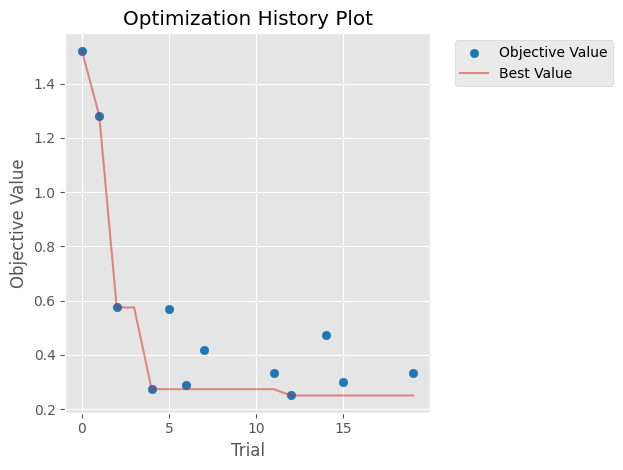

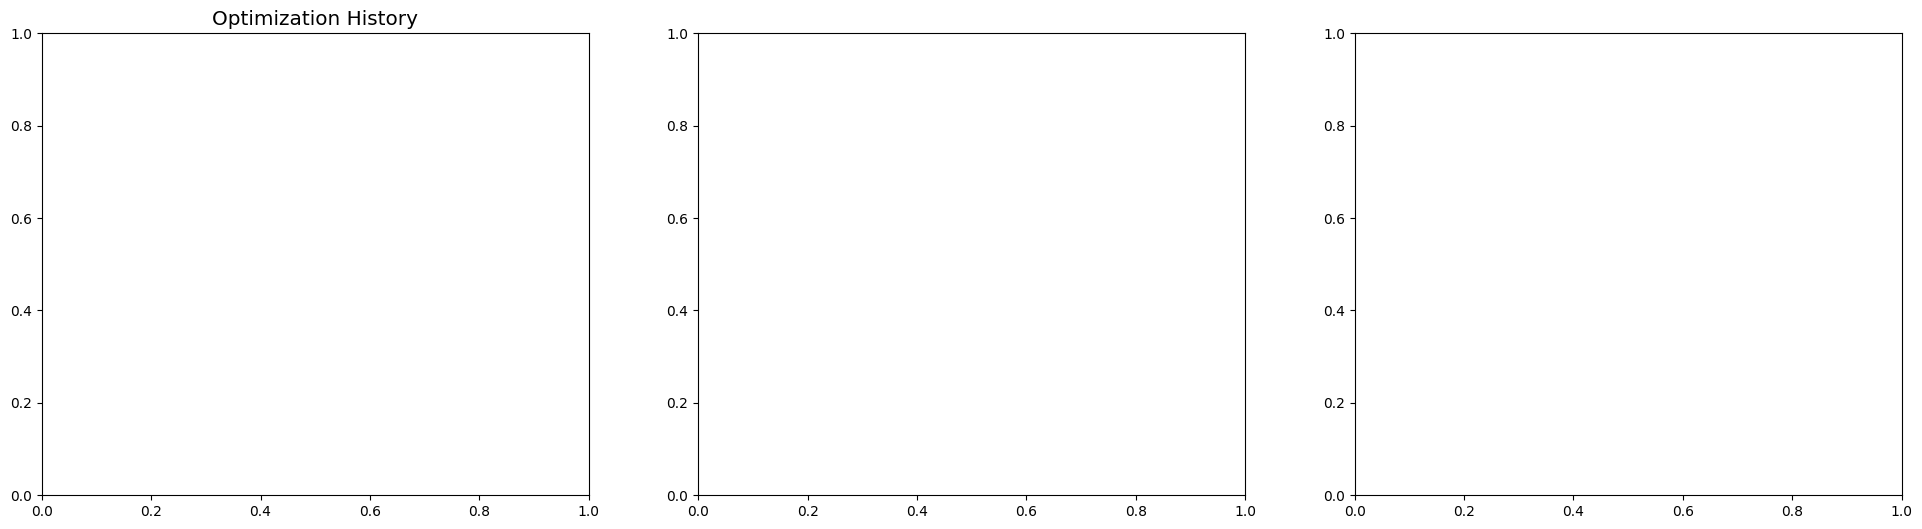

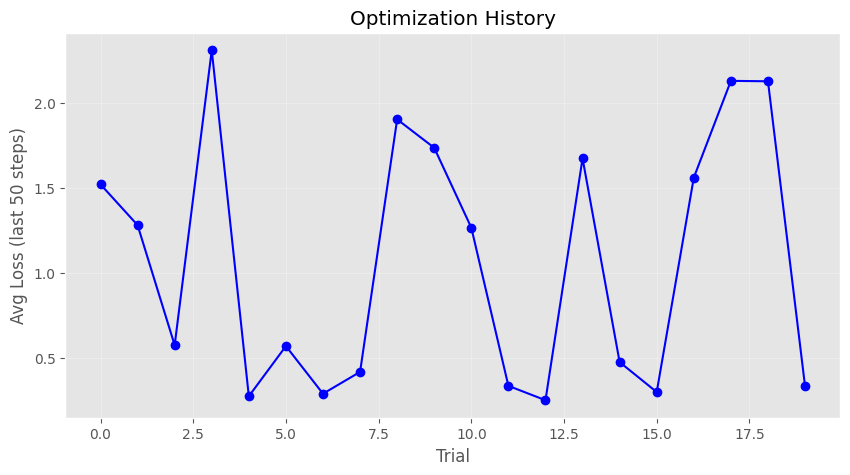

In [10]:
try:
    from optuna.visualization.matplotlib import (
        plot_optimization_history,
        plot_param_importances,
        plot_parallel_coordinate,
    )

    fig, axes = plt.subplots(1, 3, figsize=(24, 6))

    plt.sca(axes[0])
    plot_optimization_history(study)
    axes[0].set_title('Optimization History')

    plt.sca(axes[1])
    plot_param_importances(study)
    axes[1].set_title('Parameter Importances')

    plt.sca(axes[2])
    plot_parallel_coordinate(study)
    axes[2].set_title('Parallel Coordinate')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'optuna_visualization.png'), dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'Visualization failed (may need optuna[visualization]): {e}')
    # Fallback: simple plot
    completed = [t for t in study.trials if t.value is not None]
    plt.figure(figsize=(10, 5))
    plt.plot([t.number for t in completed], [t.value for t in completed], 'bo-')
    plt.xlabel('Trial')
    plt.ylabel('Avg Loss (last 50 steps)')
    plt.title('Optimization History')
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(OUTPUT_DIR, 'optuna_history.png'), dpi=150)
    plt.show()


## 9. Best Hyperparameters Summary

In [11]:
print('='*60)
print('BEST HYPERPARAMETERS')
print('='*60)
best = study.best_trial.params
print(f"  Learning Rate:           {best['learning_rate']:.6f}")
print(f"  Gradient Accumulation:   {best['gradient_accumulation_steps']}")
print(f"  Prior Loss Weight:       {best['prior_loss_weight']:.2f}")
print(f"  BOFT Block Num:          {best['boft_block_num']}")
print(f"  LR Scheduler:            {best['lr_scheduler']}")
print(f'\n  Best trial loss: {study.best_trial.value:.4f}')
print('='*60)
print('\nYou can now use these parameters to run full training at')
print(f'{FULL_TRAIN_STEPS} steps using the original demo.ipynb notebook,')
print('or continue to Section 10 below for automated full training.')


BEST HYPERPARAMETERS
  Learning Rate:           0.000186
  Gradient Accumulation:   1
  Prior Loss Weight:       1.05
  BOFT Block Num:          4
  LR Scheduler:            cosine

  Best trial loss: 0.2503

You can now use these parameters to run full training at
800 steps using the original demo.ipynb notebook,
or continue to Section 10 below for automated full training.


## 10. Full Training with Best Parameters

Re-run training with the best hyperparameters found by Optuna,
using the full `FULL_TRAIN_STEPS` (800 steps).


In [12]:
# Extract best params
best = study.best_trial.params
BEST_LR         = best['learning_rate']
BEST_GRAD_ACCUM = best['gradient_accumulation_steps']
BEST_PRIOR_W    = best['prior_loss_weight']
BEST_BLOCK_NUM  = best['boft_block_num']
BEST_LR_SCHED   = best['lr_scheduler']

print(f'Running full training with best parameters...')
print(f'  Steps: {FULL_TRAIN_STEPS}')

# Load fresh model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, subfolder='tokenizer', use_fast=False)
text_encoder = CLIPTextModel.from_pretrained(MODEL_NAME, subfolder='text_encoder').to(DEVICE, dtype=WEIGHT_DTYPE)
vae = AutoencoderKL.from_pretrained(MODEL_NAME, subfolder='vae').to(DEVICE, dtype=WEIGHT_DTYPE)
unet = UNet2DConditionModel.from_pretrained(MODEL_NAME, subfolder='unet').to(DEVICE, dtype=WEIGHT_DTYPE)
noise_scheduler = DDIMScheduler.from_pretrained(MODEL_NAME, subfolder='scheduler')

text_encoder.requires_grad_(False)
vae.requires_grad_(False)

# Apply BOFT with best block_num
boft_config = BOFTConfig(
    boft_block_num=BEST_BLOCK_NUM,
    boft_block_size=BOFT_BLOCK_SIZE,
    boft_n_butterfly_factor=BOFT_N_BUTTERFLY_FACTOR,
    boft_dropout=BOFT_DROPOUT,
    target_modules=UNET_TARGET_MODULES,
    bias='none',
)
unet = get_peft_model(unet, boft_config)
unet.train()
unet.print_trainable_parameters()

# Optimizer
optimizer = torch.optim.AdamW(
    [p for p in unet.parameters() if p.requires_grad],
    lr=BEST_LR, weight_decay=1e-2,
)
lr_sched = get_scheduler(
    BEST_LR_SCHED, optimizer=optimizer,
    num_warmup_steps=int(0.1 * FULL_TRAIN_STEPS),
    num_training_steps=FULL_TRAIN_STEPS,
)

# Dataset
dataset = DreamBoothDataset(
    INSTANCE_DIR, INSTANCE_PROMPT, CLASS_DIR, CLASS_PROMPT,
    tokenizer, size=RESOLUTION,
)
dataloader = DataLoader(dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True, num_workers=0)

# Training loop
losses = []
global_step = 0
data_iter = iter(dataloader)
pbar = tqdm(total=FULL_TRAIN_STEPS, desc='Full training')

while global_step < FULL_TRAIN_STEPS:
    try:
        batch = next(data_iter)
    except StopIteration:
        data_iter = iter(dataloader)
        batch = next(data_iter)

    pixel_values = torch.cat([batch['instance_images'], batch['class_images']]).to(DEVICE, dtype=WEIGHT_DTYPE)
    input_ids    = torch.cat([batch['instance_ids'], batch['class_ids']]).to(DEVICE)

    latents = vae.encode(pixel_values).latent_dist.sample() * vae.config.scaling_factor
    noise   = torch.randn_like(latents)
    bsz     = latents.shape[0]
    timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=DEVICE).long()
    noisy_latents  = noise_scheduler.add_noise(latents, noise, timesteps)
    encoder_hidden = text_encoder(input_ids)[0]

    model_pred = unet(noisy_latents, timesteps, encoder_hidden).sample
    target     = noise

    pred_inst, pred_cls = model_pred.chunk(2)
    tgt_inst,  tgt_cls  = target.chunk(2)
    loss = F.mse_loss(pred_inst.float(), tgt_inst.float())
    loss = loss + BEST_PRIOR_W * F.mse_loss(pred_cls.float(), tgt_cls.float())

    loss_scaled = loss / BEST_GRAD_ACCUM
    loss_scaled.backward()

    if (global_step + 1) % BEST_GRAD_ACCUM == 0:
        torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
        optimizer.step()
        lr_sched.step()
        optimizer.zero_grad()

    losses.append(loss.item())
    global_step += 1
    pbar.update(1)
    pbar.set_postfix(loss=f'{loss.item():.4f}')

pbar.close()

# Save adapter
adapter_dir = os.path.join(OUTPUT_DIR, 'best_adapter')
unet.save_pretrained(adapter_dir)
print(f'Adapter saved to {adapter_dir}')

print(f'Final loss (last 10 avg): {np.mean(losses[-10:]):.4f}')


Running full training with best parameters...
  Steps: 800


Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: sd2-community/stable-diffusion-2-1
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/home/xukai/anaconda3/envs/aist/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/home/xukai/anaconda3/envs/aist/lib/python3.12/site-packages/peft/tuners/boft/layer.py:95: UserWarning: Failed to load the CUDA extension: /home/xukai/.cache/torch_extensions/py312_cu130/fbd_cuda/fbd_cuda.so: cannot open shared object file: No such file or directory, check if ninja is available.
  warnings.warn(f"Failed to load the CUDA extension: {e}, check if nin

trainable params: 27,074,048 || all params: 892,984,772 || trainable%: 3.0319


Full training:   0%|          | 0/800 [00:00<?, ?it/s]

Adapter saved to ./data/output/boft_optuna/best_adapter
Final loss (last 10 avg): 0.4409


## 11. Training Loss Visualization

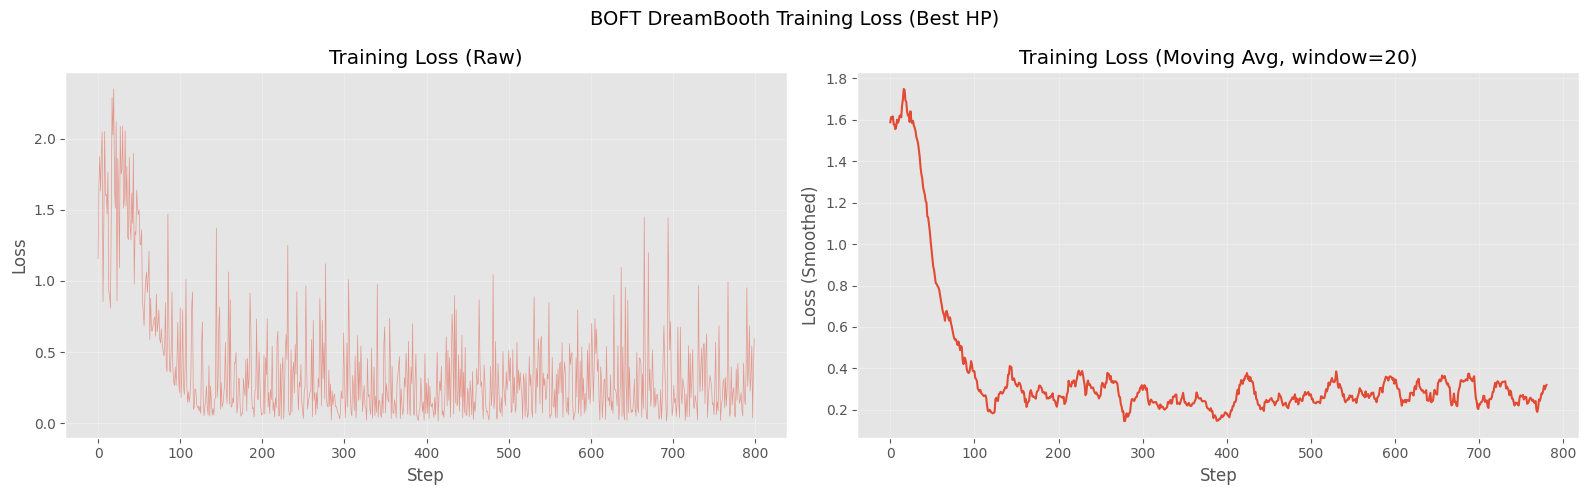

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(losses, alpha=0.5, linewidth=0.5)
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss (Raw)')
ax1.grid(True, alpha=0.3)

window = 20
if len(losses) >= window:
    smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
    ax2.plot(smoothed)
ax2.set_xlabel('Step')
ax2.set_ylabel('Loss (Smoothed)')
ax2.set_title(f'Training Loss (Moving Avg, window={window})')
ax2.grid(True, alpha=0.3)

plt.suptitle('BOFT DreamBooth Training Loss (Best HP)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'best_training_loss.png'), dpi=150, bbox_inches='tight')
plt.show()


## 12. Inference with Best Model

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /home/xukai/.cache/huggingface/hub/models--sd2-community--stable-diffusion-2-1/snapshots/bb2154823665391b4fb29b0b9cf82a198964ee05/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

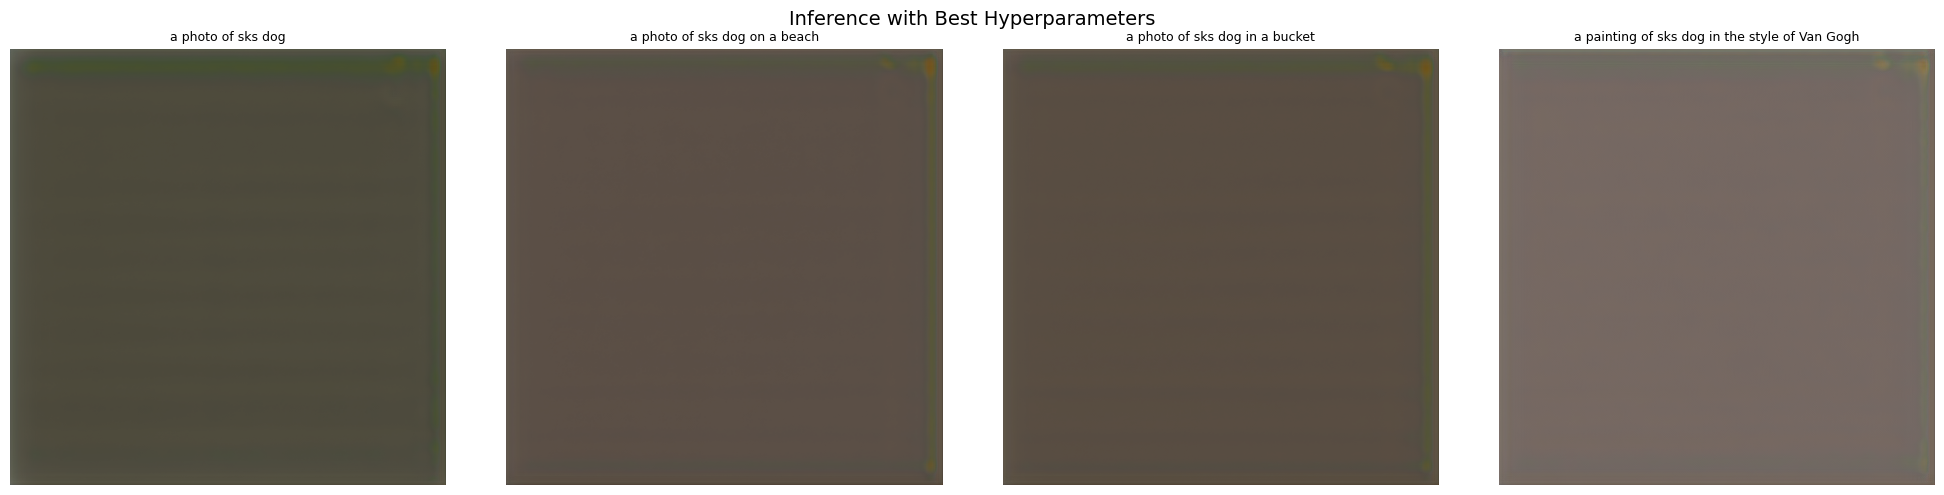

Done!


In [14]:
# Build pipeline with finetuned UNet
pipeline = StableDiffusionPipeline.from_pretrained(
    MODEL_NAME, torch_dtype=WEIGHT_DTYPE, safety_checker=None
).to(DEVICE)

# Load BOFT adapter into pipeline's UNet
pipeline.unet = PeftModel.from_pretrained(
    pipeline.unet, os.path.join(OUTPUT_DIR, 'best_adapter')
).to(DEVICE, dtype=WEIGHT_DTYPE)

pipeline.scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config)
pipeline.set_progress_bar_config(disable=False)

# Test prompts
test_prompts = [
    f'a photo of {UNIQUE_TOKEN} {CLASS_TOKEN}',
    f'a photo of {UNIQUE_TOKEN} {CLASS_TOKEN} on a beach',
    f'a photo of {UNIQUE_TOKEN} {CLASS_TOKEN} in a bucket',
    f'a painting of {UNIQUE_TOKEN} {CLASS_TOKEN} in the style of Van Gogh',
]

generator = torch.Generator(device=DEVICE).manual_seed(42)
images = []
for prompt in tqdm(test_prompts, desc='Generating'):
    img = pipeline(prompt, num_inference_steps=50, generator=generator).images[0]
    images.append(img)

fig, axes = plt.subplots(1, len(images), figsize=(5*len(images), 5))
for ax, img, prompt in zip(axes, images, test_prompts):
    ax.imshow(img)
    ax.set_title(prompt, fontsize=9, wrap=True)
    ax.axis('off')
plt.suptitle('Inference with Best Hyperparameters', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'best_inference.png'), dpi=150, bbox_inches='tight')
plt.show()

# Cleanup
del pipeline
torch.cuda.empty_cache()
gc.collect()
print('Done!')
